<!-- Container with white background -->
<div style="background-color: white; padding: 20px; border-radius: 10px;">

  <!-- Name in bold and approximate LaTeX font style with the logo blue color -->
  <h1 style="font-family: 'Times New Roman', Times, serif; font-weight: bold; color: #38549c; text-align: center;">
    Jesus Villota Miranda
  </h1>

  <!-- Project name in similar style with the logo blue color in italics -->
  <h2 style="font-family: 'Times New Roman', Times, serif; color: #38549c; text-align: center; font-style: italic;">
    Predicting Market Reactions to News: An LLM-Based Approach Using Spanish Business Articles
  </h2>

  <!-- CEMFI logo centered -->
  <div style="text-align: center; margin-bottom: 40px;">
    <img src="https://www.cemfi.es/images/Logo-Azul.png" alt="CEMFI Logo" style="width:200px;">
  </div>

  <!-- Catchy message about authorship -->
  <p style="font-family: 'Times New Roman', Times, serif; color: #38549c; text-align: center; font-size: 1.2em;">
    All code and work associated with this project are solely created and authored by Jesus Villota Miranda. © 2024
  </p>

  <!-- Contact information with logos -->
  <p style="font-family: 'Times New Roman', Times, serif; color: #38549c; text-align: center; font-size: 1em;">
    Contact:
    <a href="mailto:jesus.villota@cemfi.edu.es" style="color: #38549c;">
      <img src="https://www.logolynx.com/images/logolynx/64/64319177556c729f1806922bcd3adef5.png" alt="Email Logo" style="width: 20px; vertical-align: middle;">
      jesus.villota@cemfi.edu.es
    </a> |
    <a href="https://www.linkedin.com/in/jesusvillotamiranda/" target="_blank" style="color: #38549c;">
      <img src="https://1.bp.blogspot.com/-onvhHUdW1Us/YI52e9j4eKI/AAAAAAAAE4c/6s9wzOpIDYcAo4YmTX1Qg51OlwMFmilFACLcBGAsYHQ/s1600/Logo%2BLinkedin.png" alt="LinkedIn Logo" style="width: 20px; vertical-align: middle;">
      LinkedIn
    </a>
  </p>

</div>


# **Preamble**

## Packages

In [1]:
%reset -f

In [2]:
import os
import csv
import pandas as pd
from datetime import datetime
import numpy as np

# TEXT PROCESSING PACKAGES
from collections import defaultdict
from collections import Counter
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import SnowballStemmer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/jesusvillotamiranda/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jesusvillotamiranda/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/jesusvillotamiranda/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
# Plotting packages
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from matplotlib import rc
from wordcloud import WordCloud, ImageColorGenerator
from PIL import Image

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

## Directories

In [4]:
import yaml

def load_config(config_path):
    with open(config_path, 'r') as file:
        config = yaml.safe_load(file)
    return config

def create_project_structure(base_path, directories):
    for _, directory in directories.items():
        dir_path = os.path.join(base_path, directory)
        os.makedirs(dir_path, exist_ok=True)
        print(f"Created directory: {dir_path}")

if __name__ == "__main__":
    base_path = os.path.dirname(os.getcwd())
    config_path = os.path.join(base_path, 'config.yaml')
    config = load_config(config_path)
    create_project_structure(base_path, config['directories'])

path_raw_data       = os.path.join(base_path, config['directories']['raw_data'])
path_processed_data = os.path.join(base_path, config['directories']['processed_data'])
path_output         = os.path.join(base_path, config['directories']['output_data_description'])

Created directory: /Users/jesusvillotamiranda/Desktop/Replication_Package/data/raw
Created directory: /Users/jesusvillotamiranda/Desktop/Replication_Package/data/processed
Created directory: /Users/jesusvillotamiranda/Desktop/Replication_Package/notebooks
Created directory: /Users/jesusvillotamiranda/Desktop/Replication_Package/output/descriptives
Created directory: /Users/jesusvillotamiranda/Desktop/Replication_Package/output/kmeans
Created directory: /Users/jesusvillotamiranda/Desktop/Replication_Package/output/llama


## Plotting Parameters

In [5]:
TITLE_FONTSIZE  = 18
LABEL_FONTSIZE  = 20
TICK_FONTSIZE   = 18
LEGEND_FONTSIZE = 16

TITLE_PAD       = 20
LABEL_PAD       = 20

#
---
---

# **Functions**

In [6]:
def split_data(D, split1=0.8, split2=0.8, split2_type='sequential', seed=42, verbose=False):
    """
    Prepare the dataset by splitting into training, validation, and test sets,
    and scaling the embeddings. Adds a column to the original DataFrame indicating the set.

    Parameters:
    D (pd.DataFrame): The input dataframe containing 'embeddings' column.
    split1 (float): Proportion of data to use for training and validation (default 0.8).
    split2 (float): Proportion of the split1 data to use for training (default 0.8).
    split2_type (str): Type of split for training and validation ('sequential' or 'random').
    verbose (bool): Whether to print detailed split information (default False).

    Returns:
    dict: A dictionary containing the splits and scaled embeddings, and the original DataFrame with set labels.
    """
    
    if not (0 < split1 <= 1) or not (0 < split2 <= 1):
        raise ValueError("`split1` and `split2` must be between 0 and 1.")

    n_split1 = int(split1 * D.shape[0])
    n_split2 = int(split2 * n_split1)

    # Create the test set
    D_test = D.iloc[n_split1:]

    if split2_type == 'sequential':
        D_train = D.iloc[:n_split2]
        D_val   = D.iloc[n_split2:n_split1]

    elif split2_type == 'random':
        D_split2 = D.iloc[:n_split1]
        D_train  = D_split2.sample(n=n_split2, random_state=seed)  # Sample n_split2 rows for training
        D_val    = D_split2.drop(D_train.index)  # The remaining rows for validation

    else:
        raise ValueError("`split2_type` must be either 'sequential' or 'random'.")

    # e_data = get_e_data(D_train, D_val, D_test)

    # Add a new column to indicate the split each row belongs to
    D_new = D.copy()
    D_new.loc[D_train.index, 'split']  = 'Train'
    D_new.loc[D_val.index, 'split']    = 'Validation'
    D_new.loc[D_test.index, 'split']   = 'Test'

    split_data = {
        'D': D_new,
        'D_train': D_train,
        'D_val': D_val,
        'D_test': D_test,
    }

    if verbose:
        train_percentage = split1 * split2 * 100
        val_percentage = split1 * (1 - split2) * 100
        test_percentage = (1 - split1) * 100
        print(f"SPLIT: [ Train ({train_percentage:.2f}%) | Validation ({val_percentage:.2f}%) | Test ({test_percentage:.2f}%) ] ---- Train-Validation split: {split2_type}")

    return split_data

In [7]:
def histogram_and_density(df, title, xlabel, ylabel_left, ylabel_right, xlim, save_output=False):
    # Create figure and axis objects
    fig, ax1 = plt.subplots(figsize=(10, 6))
    rc('text', usetex=True)  # enable LaTeX commands in text
    rc('font', family='serif')  # set serif as the default font

    # Background color of the plot area
    ax1.set_facecolor('#f5f5f5')  # comment to go back to default

    # Histogram (frequencies)
    counts, bins, patches = ax1.hist(df, bins=30, color='skyblue', edgecolor='black', alpha=0.7, label='Histogram')

    # Create secondary y-axis
    ax2 = ax1.twinx()

    # Density
    df.plot(kind='density', color='orange', ax=ax2, label='Density')

    # Set labels and title
    ax1.set_xlabel('', fontsize=30, labelpad=LABEL_PAD)
    ax1.set_ylabel(ylabel_left, fontsize=22, labelpad=LABEL_PAD)
    ax2.set_ylabel(ylabel_right, fontsize=22, labelpad=LABEL_PAD)

    plt.title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_PAD) if not save_output else None

    ax1.set_xlim(*xlim)  # Unpack tuple for xlim
    ax1.tick_params(axis='both', which='major', labelsize=24)
    ax2.tick_params(axis='y', labelsize=24)

    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)

    # Legend
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, fontsize=22)

    ax1.grid(True, linestyle=':', linewidth=0.5, color='gray', alpha=0.3)

    # plt.grid(True)
    plt.savefig(os.path.join(path_output, f'{title.replace(" ", "_")}.pdf'), bbox_inches='tight') if save_output else None
    plt.show()


# Text processing functions
########################################################################################################

def preprocess_text(text):
    # Tokenize the text
    tokens = word_tokenize(text.lower(), language='spanish')
    # Remove punctuation
    tokens = [token for token in tokens if token not in string.punctuation]
    # Remove stopwords
    stop_words = set(stopwords.words('spanish'))
    tokens = [token for token in tokens if token not in stop_words]
    # Remove punctuation and symbols
    tokens = [word for word in tokens if word.isalpha()]
    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    # # Remove tokens with length <= 2
    # tokens = [token for token in tokens if len(token) > 2]
    # Remove stopwords
    tokens = [word for word in tokens if word.lower() not in stop_words]
    # # Lowercase the text 
    # tokens = [word.lower() for word in tokens]
    vocabulary_size = Counter(tokens)
    # Join tokens back into a single string
    processed_text = ' '.join(tokens)
    return processed_text

########################################################################################################

def vocabulary_filter(text):
    words = word_tokenize(ProcessedText.lower(), language='spanish')
    word_counts = Counter(words)
    #####################################################################################
    ## FREQUENT WORDS
    threshold = 0.002
    max_word_count = int(len(words) * threshold)  # I set it to be 8% of total word counts
    frequent_words = [word for word in words if word_counts[word] >= max_word_count]
    frequent_words_unique = list(set(frequent_words))
    frequent_words_size = len(frequent_words_unique)
    frequent_words_counts = Counter(frequent_words)
    print('_'*200)
    print('Frequent Words')
    print(f'- Definition: words that appear more than {max_word_count} times (i.e: they appear more than {threshold*100}% of total word count)')
    print(f'- {frequent_words_counts}')
    print(f'- Vocabulary size: {frequent_words_size}')
    #####################################################################################
    ## INFREQUENT WORDS
    min_word_count = 1
    infrequent_words = [word for word in words if word_counts[word] <= min_word_count]
    infrequent_words_unique = list(set(infrequent_words))
    infrequent_words_size = len(infrequent_words_unique)
    infrequent_words_counts = Counter(infrequent_words)
    print('_'*200)
    print('Infrequent Words')
    print(f'- Definition: words that appear less than {min_word_count} times')
    print(f'- {infrequent_words_counts}')
    print(f'- Vocabulary size: {infrequent_words_size}')
    #####################################################################################
    ## FILTERED WORDS
    filtered_words = [word for word in words if word_counts[word] > min_word_count and word_counts[word] < max_word_count]
    vocab_original = list(set(words))
    vocab_filtered = list(set(filtered_words))
    print('_'*200)
    print('Vocabulary report')
    print(f'** The original vocabulary consisted of {len(vocab_original)} words')
    print(f'** We eliminated words without meaningful information; i.e. Infrequent Words (appear <= {min_word_count} times) & Frequent Words (appear >= {max_word_count} times)')
    print(f'** After filtering, the vocabulary consists of {len(vocab_filtered)} different words')
    vocabulary_filtered =  Counter(filtered_words)
    print(f'** The filtered vocabulary is {vocabulary_filtered}')
    # join all the filtered_words
    filtered_text = ' '.join(filtered_words)
    return filtered_text

#
---
---

# **Data**

In [8]:
D = pd.read_csv(os.path.join(path_processed_data, 'D.csv'))
D.drop(columns=['tickers'], inplace=True) # drop the 'tickers' column

# Split the Data
split_dict = split_data(D, split1=0.8, split2=0.6, split2_type='sequential', verbose=False)
D = split_dict['D'] 

D

,publ_datetime,articles,split
0,2020-06-24 10:54:05.338,Permanencia de los Benetton en accionariado Ce...,Train
1,2020-06-24 11:21:20.603,Retomar subastas renovables en España sería bu...,Train
2,2020-06-24 11:41:30.560,Presidente Telefónica prevé consolidación en s...,Train
3,2020-06-24 12:24:06.662,Amadeus saldrá reforzado de esta crisis -Sabad...,Train
4,2020-06-24 13:06:15.907,Fondo Polygon solicita a CNMV que analice y al...,Train
...,...,...,...
2608,2021-09-30 09:04:24.715,Naturgy afirma que no ha considerado revisar r...,Test
2609,2021-09-30 09:36:48.822,No hay peligro de recorte de dividendo en Natu...,Test
2610,2021-09-30 11:25:13.398,Merlin Properties pone a la venta cartera de s...,Test
2611,2021-09-30 15:24:35.975,Banco Sabadell rebaja de 1.936 a 1.730 las per...,Test


# 
---
---

# **Histogram: Number of Words per Article**

In [9]:
# Count the number of words in each document
D_word_count = D['articles'].apply(lambda x: len(x.split())).to_frame()
D_word_count.reset_index(drop=True, inplace=True)
D_word_count.columns = ['word_count']

D_word_count.describe()

,word_count
count,2613.000000
mean,268.198240
std,199.801649
min,62.000000
25%,140.000000
50%,189.000000
75%,325.000000
max,1405.000000


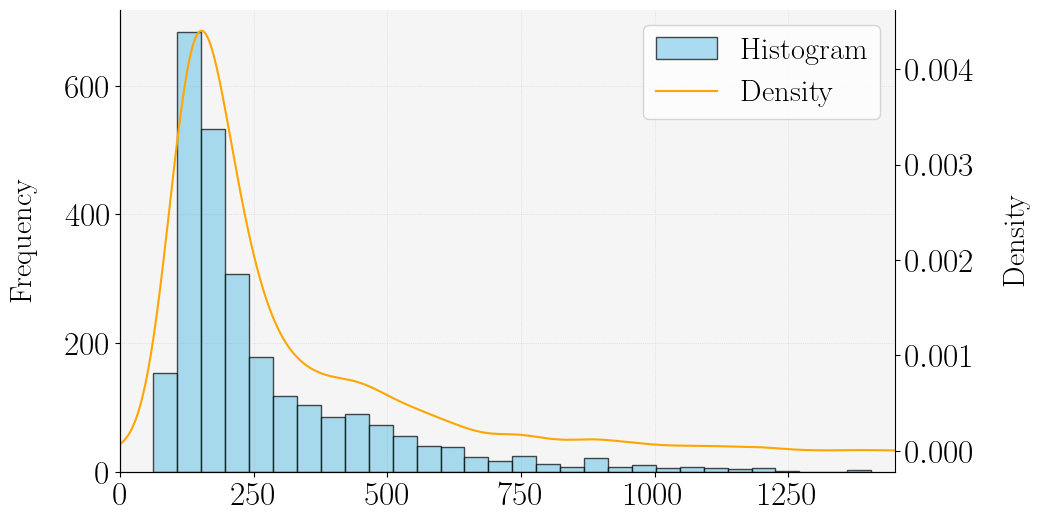

In [10]:
histogram_and_density(D_word_count['word_count'], 'Number of Words per Article', 'Word Count', 'Frequency', 'Density', (0, 1450), save_output=True)

# 
---
---

# **TS & Histogram: Number of News Articles per Day**

In [11]:
# Extract the publication date
D['publ_date'] = D['publ_datetime'].apply(lambda x: x.split()[0]) # in the publ_datetime column, the date is in the format 'YYYY-MM-DD HH:MM:SS', here we convert it to 'YYYY-MM-DD'

# Group by publication date and drop the publ_datetime and split columns
D_ts = D.groupby('publ_date').count()
D_ts.drop(columns=['publ_datetime', 'split'], inplace=True)

# Compute the Moving Average
MA_window = 30
D_ts[f'MA({MA_window})'] = D_ts['articles'].rolling(window=MA_window).mean()

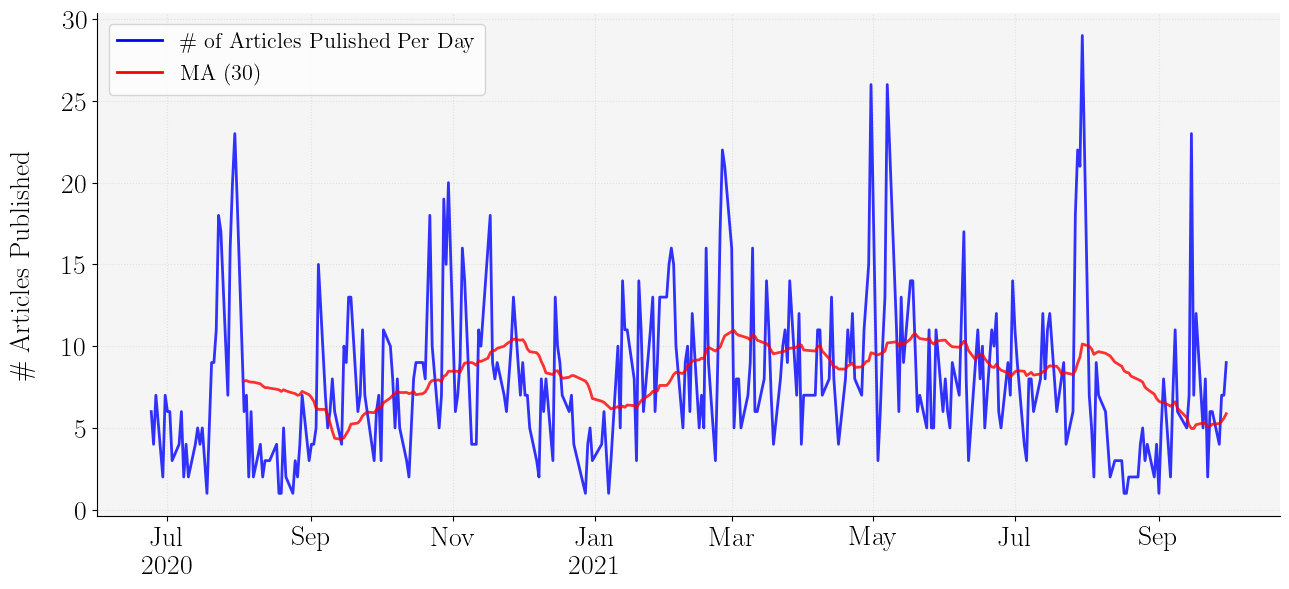

In [12]:
save_this_plot = True

#===============================================================================================================

# Custom date formatter
class CustomDateFormatter(mdates.DateFormatter):
    def __init__(self, fmt="%b-%Y", *args, **kwargs):
        super().__init__(fmt, *args, **kwargs)
        self.fmt = fmt
        self.last_year = None

    def __call__(self, x, pos=0):
        dt = mdates.num2date(x)
        if self.last_year != dt.year:
            self.last_year = dt.year
            return dt.strftime("%b\n%Y")
        else:
            return dt.strftime("%b")      # Uncomment for: Months in TEXTUAL format
            # return dt.strftime("%m")    # Uncomment for: Months in NUMERIC format
        
#===============================================================================================================

df = D_ts.copy()
df.index = pd.to_datetime(df.index)

fig, ax = plt.subplots(figsize=(13, 6))

rc('text', usetex=True) # enable LaTeX commands in text
rc('font', family='serif') # set serif as the default font  

# Set title, labels, and customize grid
title = 'Number of Articles Published'
ax.set_title('Time Series of \# Articles per Day', fontsize=TITLE_FONTSIZE, pad=TITLE_PAD) if not save_this_plot else None
ax.set_xlabel('', fontsize=LABEL_FONTSIZE, labelpad=LABEL_PAD)
ax.set_ylabel(r'\# Articles Published', fontsize=LABEL_FONTSIZE, labelpad=LABEL_PAD)
ax.grid(True, alpha=0.3, linestyle=':')

# Hide top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set the background color to grey
ax.set_facecolor('#f5f5f5')

colors = {'articles': 'blue', 'MA(30)': 'red'}

# Plotting data
for col in df.columns:
    ax.plot(df.index, df[col], color=colors[col], linewidth=2, alpha=0.8, label=col)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_formatter(CustomDateFormatter())          
ax.tick_params(axis='both', which='major', labelsize=20)

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='blue', lw=2, label=r'\# of Articles Pulished Per Day'),
                   Line2D([0], [0], color='red', lw=2, label='MA (30)')]


ax.legend(handles=legend_elements, fontsize=LEGEND_FONTSIZE)

# plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(os.path.join(path_output, 'Time_Series_of_Articles.pdf'), bbox_inches='tight') if save_this_plot else None

plt.show()

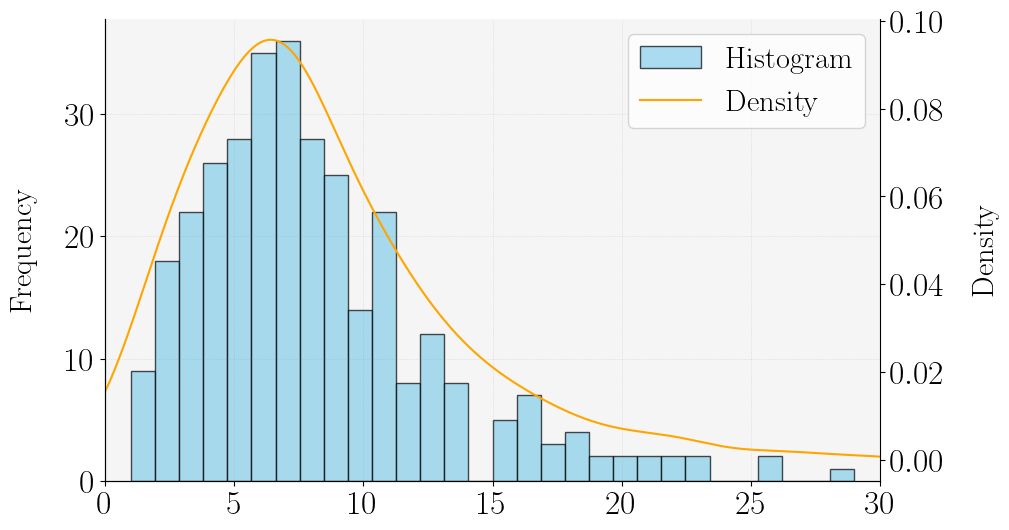

In [13]:
histogram_and_density(df['articles'], 'Histogram of Number of News Articles per day',  'Number of News Articles per day', 'Frequency', 'Density', xlim=(0, 30), save_output=True)

# 
---
---

# **Word Cloud**

In [14]:
# merge all the dcouments of D into a single document
D_join_all = ' '.join(D['articles'].tolist())

# Number of words in the whole sample
print(f'There are {len(D_join_all.split())} words in the whole sample')

ProcessedText = preprocess_text(D_join_all)

There are 700802 words in the whole sample


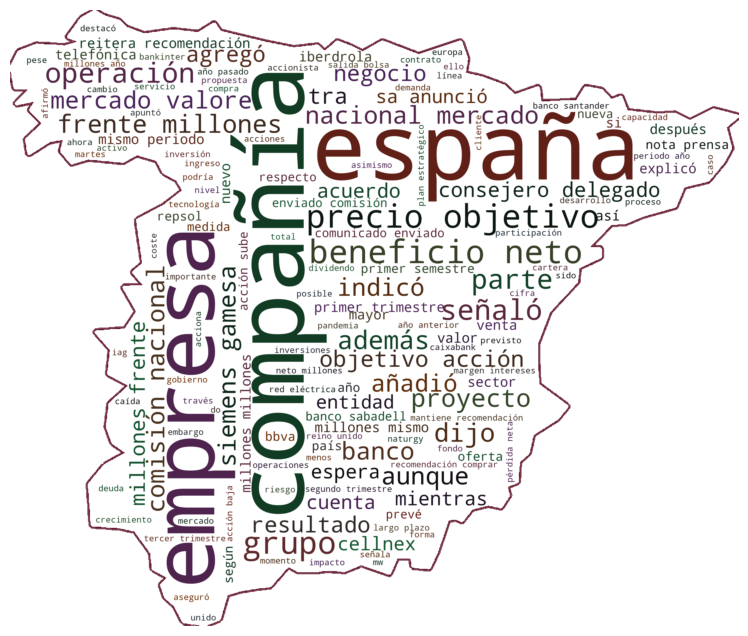

In [15]:
save_this_plot = True

#===============================================================================================================

spain_mask = np.array(Image.open(os.path.join(path_raw_data, 'Spain_Contour_for_Word_Cloud.png')))

# Define a custom colormap with dark colors
colors = ["#1B2631", "#6E2C00", "#4A235A", "#0B0B0B", "#145A32", "#641E16"]
custom_cmap = LinearSegmentedColormap.from_list("custom_dark", colors, N=150)

def generate_better_wordcloud(data, title, mask=None):
    stopwords_set = set(stopwords.words('spanish'))
    
    cloud = WordCloud(
        scale=3,
        max_words=150,
        colormap=custom_cmap,  # Use the custom dark colormap
        mask=mask,
        background_color='white',
        stopwords=stopwords_set,
        collocations=True,
        contour_color='#5d0f24',
        contour_width=3
    ).generate(data)
    
    plt.figure(figsize=(10, 8))
    plt.imshow(cloud, interpolation='bilinear')
    plt.axis('off')

    plt.title(title) if not save_this_plot else None
    plt.savefig(os.path.join(path_output, f'WordCloud.pdf'), bbox_inches='tight') if save_this_plot else None

    plt.show()


generate_better_wordcloud(ProcessedText, '', mask=spain_mask)


#
---
---

# **LaTeX Table with Data Descriptives on each Split**

In [16]:
save_this_table = True

#===============================================================================================

# Function to calculate the statistics for a given split
def calculate_split_stats(split_df):
    split_df = split_df.copy()
    split_df['publ_date'] = pd.to_datetime(split_df['publ_date'])
    time_period = f"{split_df['publ_date'].min().strftime('%d/%m/%Y')} $-$ {split_df['publ_date'].max().strftime('%d/%m/%Y')}"
    num_articles = split_df.shape[0]
    all_words = ' '.join(split_df['articles']).split()
    num_words = len(all_words)
    vocab_size = len(set(all_words))
    return time_period, num_articles, num_words, vocab_size

# Calculate stats for each split and the whole data
splits = ['All', 'Train', 'Validation', 'Test']
dataframes = {
    'All': D,
    'Train': D[D['split'] == 'Train'],
    'Validation': D[D['split'] == 'Validation'],
    'Test': D[D['split'] == 'Test']
}

results = []
for split_name, df in dataframes.items():
    time_period, num_articles, num_words, vocab_size = calculate_split_stats(df)
    results.append([split_name, time_period, num_articles, num_words, vocab_size])

# Create a dataframe for the results
results_df = pd.DataFrame(results, columns=['Data Split', 'Time Period', r'\# Articles', r'\# Words', 'Vocabulary Size'])

# Convert the results dataframe to a LaTeX table string
table_latex = results_df.to_latex(index=False, column_format='lcccc', 
                                  header=['Data Split', 'Time Period', r'\# Articles', r'\# Words', 'Vocabulary Size'])

# Add row color to the header
header_row_color = r"""
\rowcolor{gray!10}
"""

# Insert the row color before the header row
table_latex = table_latex.replace("\\toprule\n", "\\toprule\n" + header_row_color)

# Define the complete LaTeX table environment with caption and label
table_env = r"""\begin{table}[H]
\centering
\caption{Summary Statistics of Articles by Data Split}
\label{tab:summary_stats}
""" + table_latex + r"""
\end{table}
"""

print(table_env)

if save_this_table:
    with open(path_output + f'/Articles_by_SplitSummary_Statistics.tex', 'w') as file:
        file.write(table_env)


\begin{table}[H]
\centering
\caption{Summary Statistics of Articles by Data Split}
\label{tab:summary_stats}
\begin{tabular}{lcccc}
\toprule

\rowcolor{gray!10}
Data Split & Time Period & \# Articles & \# Words & Vocabulary Size \\
\midrule
All & 24/06/2020 $-$ 30/09/2021 & 2613 & 700802 & 42600 \\
Train & 24/06/2020 $-$ 12/02/2021 & 1254 & 327405 & 26759 \\
Validation & 12/02/2021 $-$ 21/06/2021 & 836 & 232906 & 22262 \\
Test & 21/06/2021 $-$ 30/09/2021 & 523 & 140491 & 16471 \\
\bottomrule
\end{tabular}

\end{table}



#
---
---